<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/alba_HeartCycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [53]:
import os
import pandas as pd
from google.colab import drive
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# mount Google Drive
drive.mount('/content/drive')
dir_path = "/content/drive/MyDrive/Data_HeartCycle/59146237"

# # list files
# files = os.listdir(dir_path)
# print("\nAvailable files:")
# for i, file in enumerate(files):
#     print(f"{i}: {file}")

# # file selection
# file_index = int(input("\nEnter file number: "))
# file_path = os.path.join(dir_path, files[file_index])

file_path = '/content/drive/MyDrive/Data_HeartCycle/59146237/59146237_s0000005.mat'
data_hc = sio.loadmat(file_path)
print(data_hc.keys())

header = data_hc['__header__']
#print(header)
#b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Thu Mar 12 19:36:31 2009'

version = data_hc['__version__']
#print(version)
# 1.0

globals = data_hc['__globals__']
#print(globals)
# []

measures = data_hc['measure']
#print(measures)

print(type(measures))        # ndarray
print(measures.shape)       # 30 rows and 5 columns

rows, cols = measures.shape # measures is a 30x5 ndarray
# to find out how many signals we have
for i in range(rows):
    for j in range(cols):
        try:
            label = measures[i, j]['label'][0, 0]
            print(f"measures[{i},{j}] -> {label}")
        except:
            continue

print(measures[1,1]['label'][0]) #ICG

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dict_keys(['__header__', '__version__', '__globals__', 'measure'])
<class 'numpy.ndarray'>
(30, 5)
measures[0,0] -> ['Event']
measures[0,1] -> ['ECG']
measures[0,2] -> ['ECG']
measures[0,3] -> ['ECG']
measures[0,4] -> ['ECG']
measures[1,0] -> ['SPO2']
measures[1,1] -> ['IMP']
measures[1,2] -> ['PCG']
measures[1,3] -> ['ECHO']
measures[1,4] -> ['PPG']
measures[2,0] -> ['O/C']
measures[2,1] -> ['RPEAKS']
measures[2,2] -> ['RPEAKS']
measures[2,3] -> ['RPEAKS']
measures[2,4] -> ['RPEAKS']
measures[3,0] -> ['Load']
measures[3,1] -> ['AVO']
measures[3,2] -> ['AVO']
measures[3,3] -> ['AVO']
measures[3,4] -> ['AVO']
measures[4,0] -> ['HPD']
measures[4,1] -> ['PPEjec']
measures[4,2] -> ['PEP']
measures[4,3] -> ['PEP']
measures[4,4] -> ['PEP']
measures[5,0] -> ['DC']
measures[5,1] -> ['AVC']
measures[5,2] -> ['AVC']
measures[5,3] -> ['AVC']
measures[5,4] -> ['AVC']
mea

# ICG + Preprocess

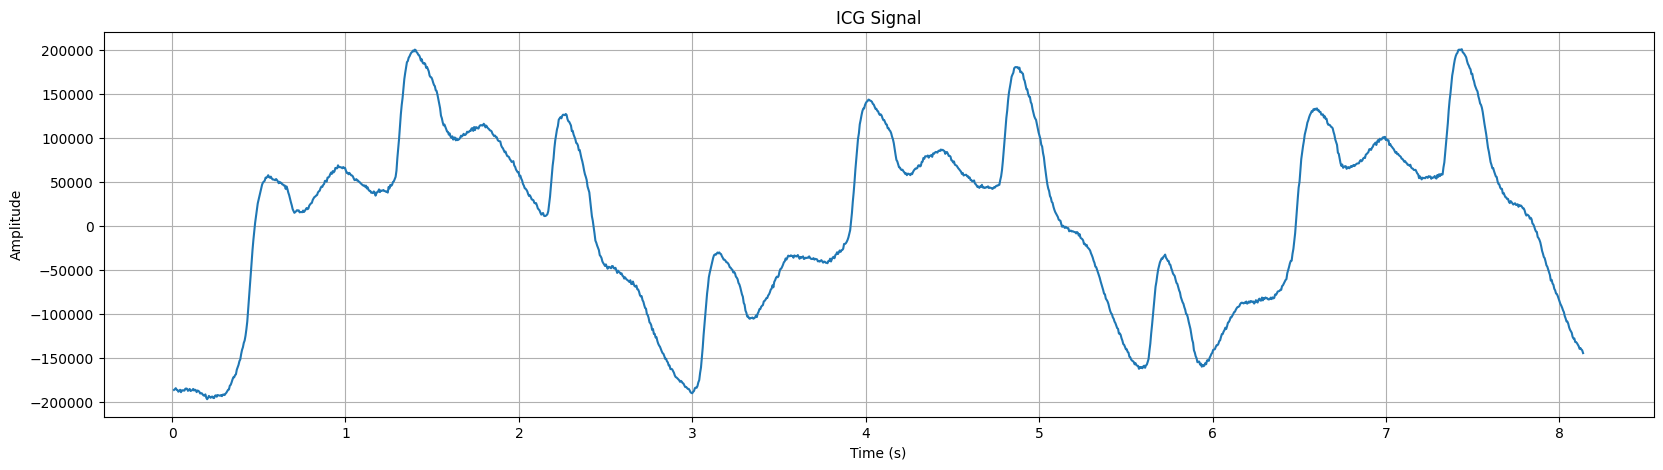

In [54]:
import matplotlib.pyplot as plt

icg = measures[1,1] #extract the ICG signal
icg_time = icg['time'][0,0].flatten()
icg_data = icg['data'][0,0].flatten()

plt.figure(figsize=(20, 5))
plt.plot(icg_time, icg_data)
plt.title('ICG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## ICG Preprocessing
The most important artifacts affecting the ICG signal are sinusoidal, respiratory, muscle, and electrode artifacts [ReBeat]
- Sinusoidal: power line -> band pass
- Respiratory: very low frequency -> band pass with low cutoff 0.5 and also SG filter [ReBeat]
- Muscle: very high frequency -> band pass with high cutoff 20 for example?
- Electrode: bad contact, movement -> wavelet

## Band pass filter

In [55]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

dt = np.mean(np.diff(icg_time))      #time step, we calculate the average interval between consecutive time samples
fs = 1 / dt                          #sampling frequency
#print(fs) #198.45387059502093

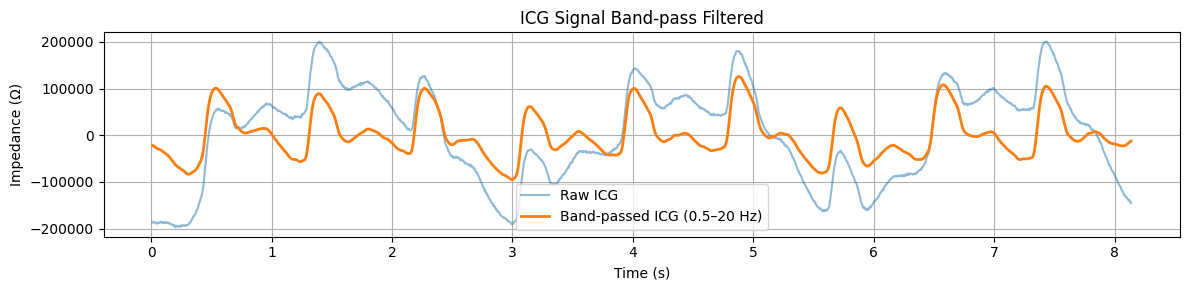

In [56]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)
icg_bandpassed = bandpass(icg_data, fs,0.5,20)

plt.figure(figsize=(12, 3))
plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG (0.5–20 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Impedance (Ω)')
plt.title('ICG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Savitzky-Golay filter

If we overlay the bandpassed ICG and the SG ICG we see they overlap, suggesting that SG is not actually helping.
We used SG as a smoothing filter:
- It smooths out high-frequency noise, it preserves local shape, but it may flatten sharp peaks
- We're replacing the signal with a smoothed version

The Savitzky-Golay filter is a smoothing filter based on local polynomial regression. Instead of simply averaging neighboring points (like a moving average does), SG fits a polynomial curve to a small window of the data, and replaces the center point with the value predicted by that polynomial

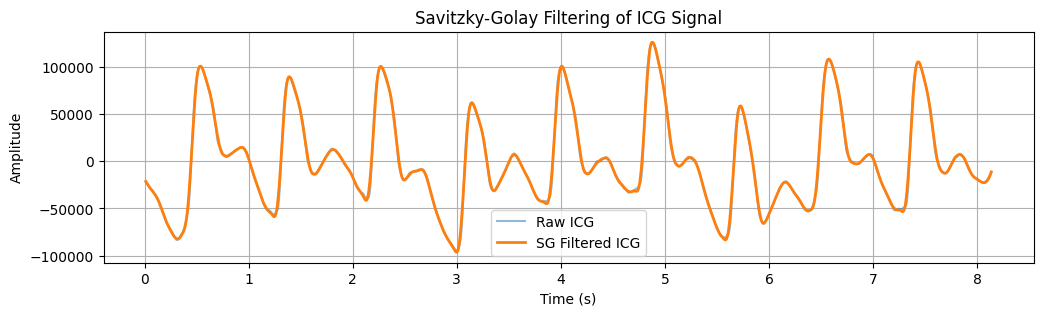

In [57]:
from scipy.signal import savgol_filter

icg_sg = savgol_filter(icg_bandpassed, window_length=31, polyorder=3)

plt.figure(figsize=(12,3))
plt.plot(icg_time, icg_bandpassed, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_sg, label='SG Filtered ICG', linewidth=2)
plt.legend()
plt.title("Savitzky-Golay Filtering of ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

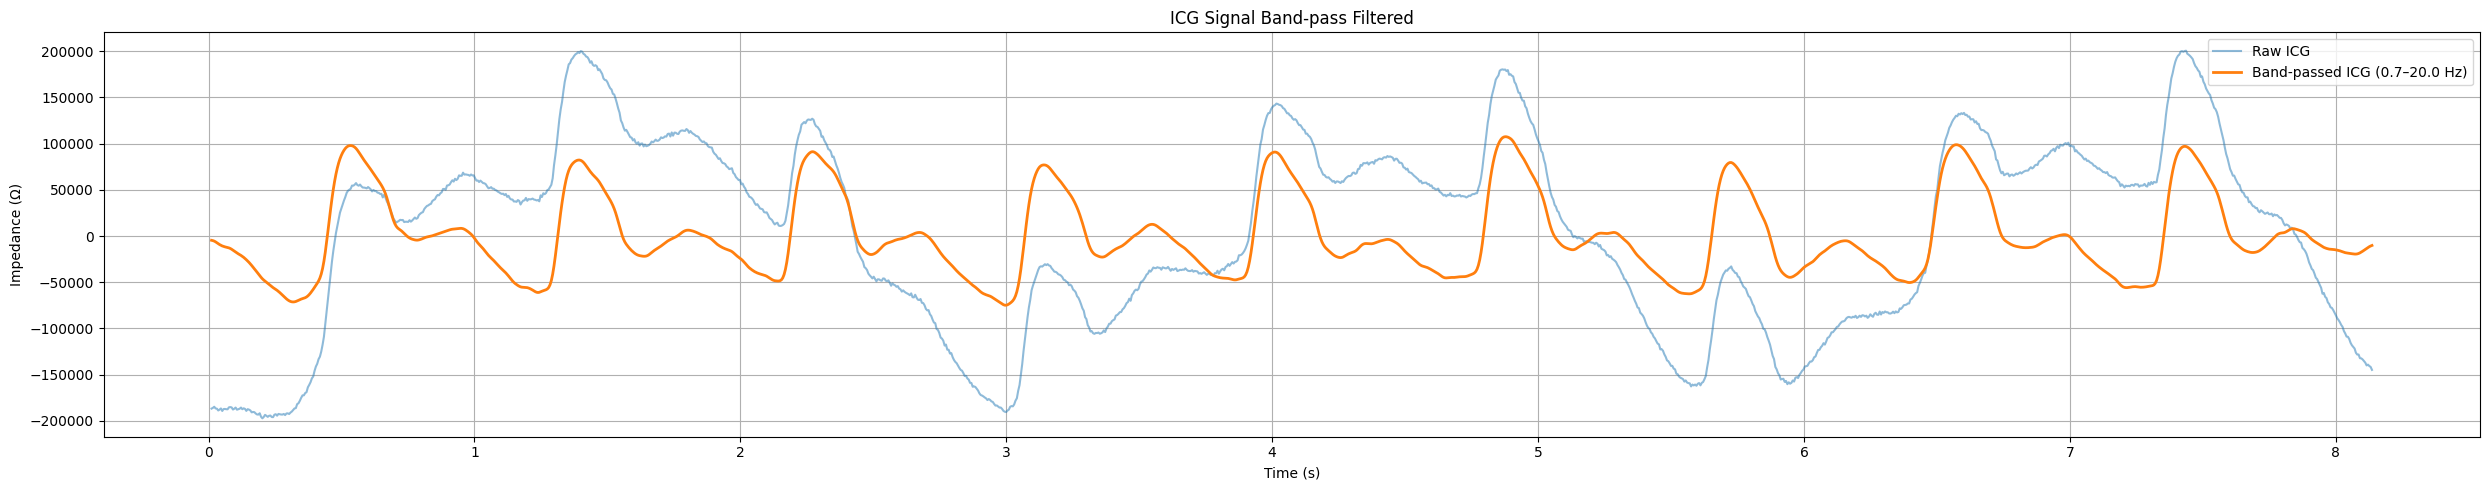

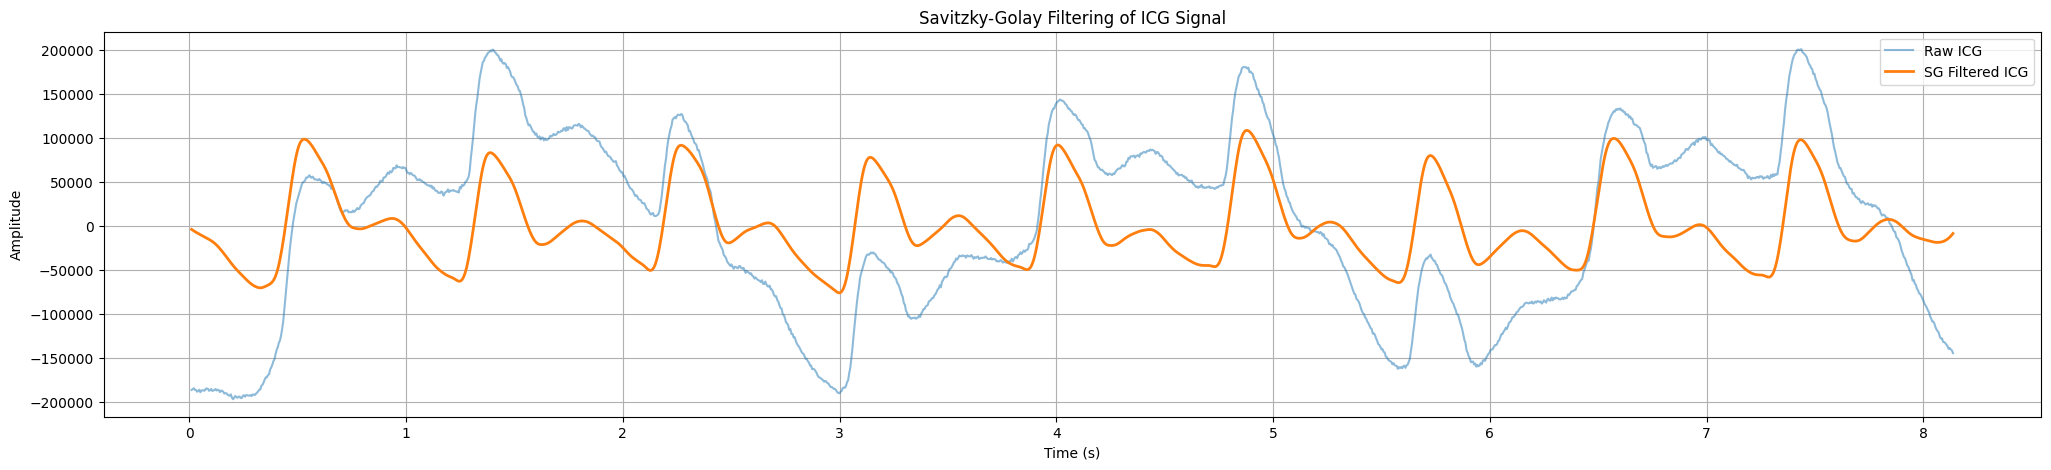

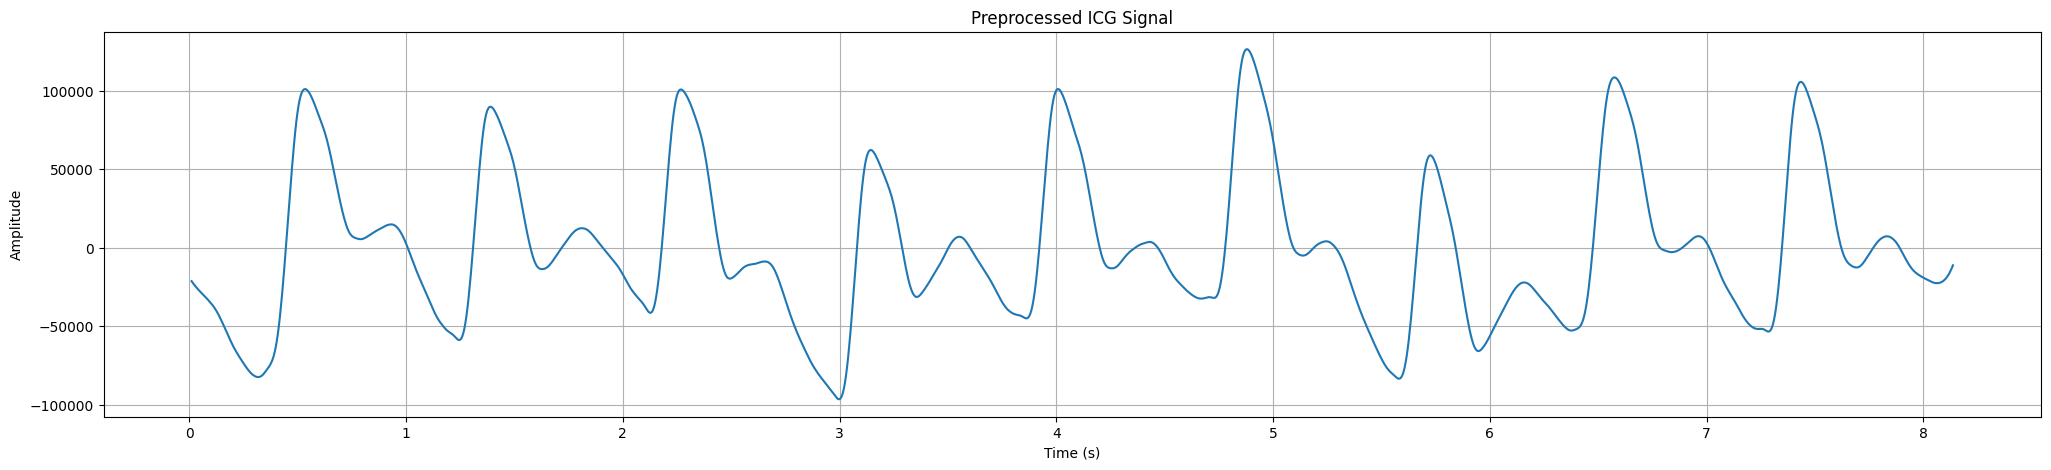

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter

def preprocess_icg(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=31, sg_poly=3):
    """
    Preprocess ICG signal: Bandpass filtering + Savitzky-Golay smoothing

    Parameters:
        icg_data (array): Raw ICG signal.
        icg_time (array): Time vector for the ICG signal.
        fs (float): Sampling frequency.
        lowcut (float): Low cutoff frequency for bandpass filter.
        highcut (float): High cutoff frequency for bandpass filter.
        order (int): Order of the Butterworth filter.
        sg_window (int): Window length for Savitzky-Golay filter (must be odd).
        sg_poly (int): Polynomial order for Savitzky-Golay filter.

    Returns:
        icg_sg (array): Smoothed ICG signal after preprocessing.
    """
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Plot: Raw vs Band-passed
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
    plt.plot(icg_time, icg_bandpassed, label=f'Band-passed ICG ({lowcut}–{highcut} Hz)', linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Impedance (Ω)')
    plt.title('ICG Signal Band-pass Filtered')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Savitzky-Golay smoothing
    icg_sg = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)

    # Plot: Band-passed vs SG-smoothed
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
    plt.plot(icg_time, icg_sg, label='SG Filtered ICG', linewidth=2)
    plt.legend()
    plt.title("Savitzky-Golay Filtering of ICG Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

    return icg_sg

icg_processed = preprocess_icg(icg_data, icg_time, fs)

plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_sg)
plt.title("Preprocessed ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

## Baseline removal

As we see this is not helping we use SG as a baseline corrector, we use SG to estimate the low-frequency trend (baseline), and then subtract it. Here, SG isn’t used to smooth the signal but to isolate the low-frequency component (like respiration or motion drift)

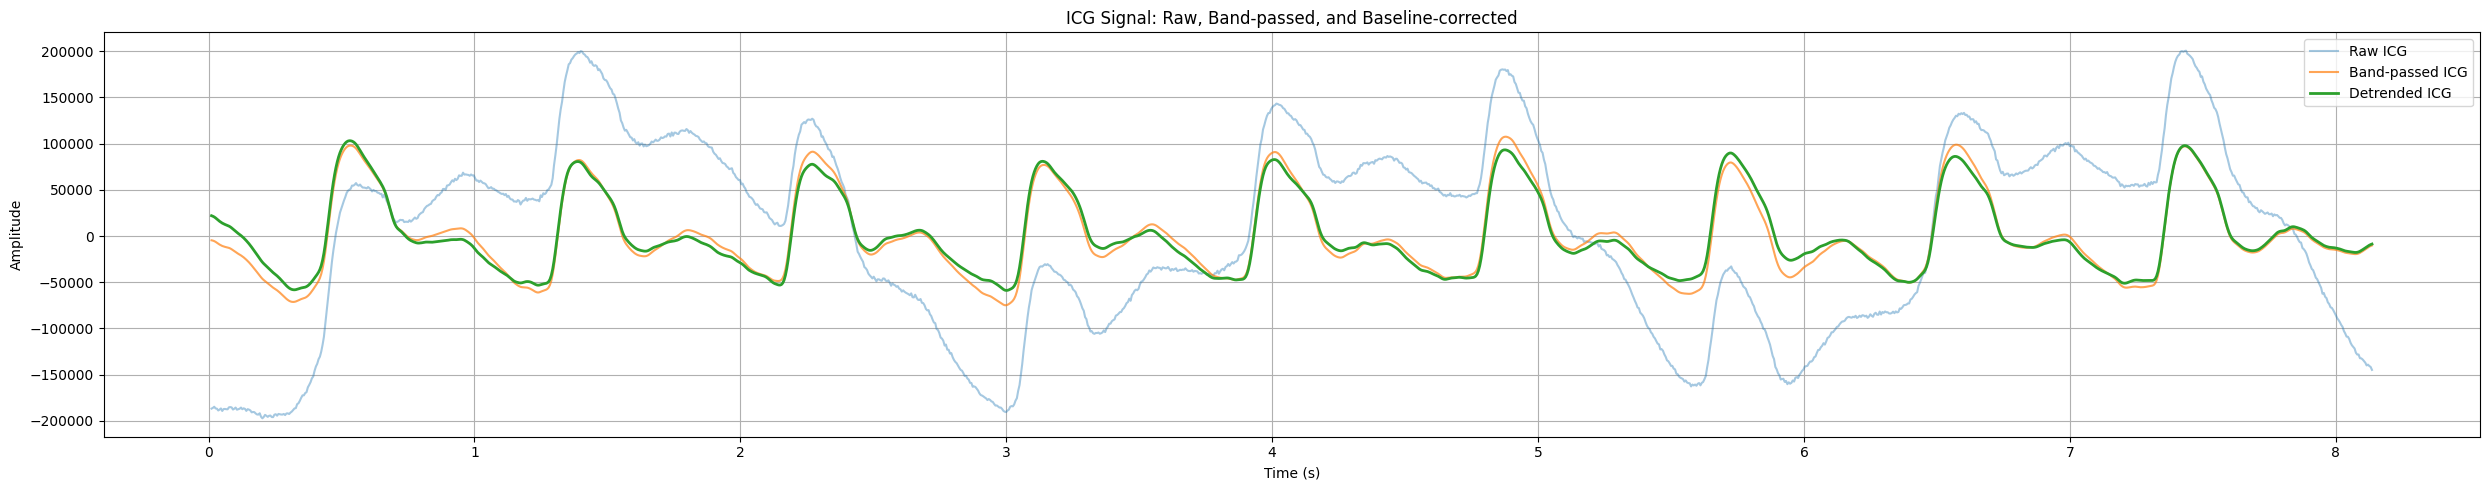

Text(0.5, 1.0, 'Preprocessed ICG Signal')

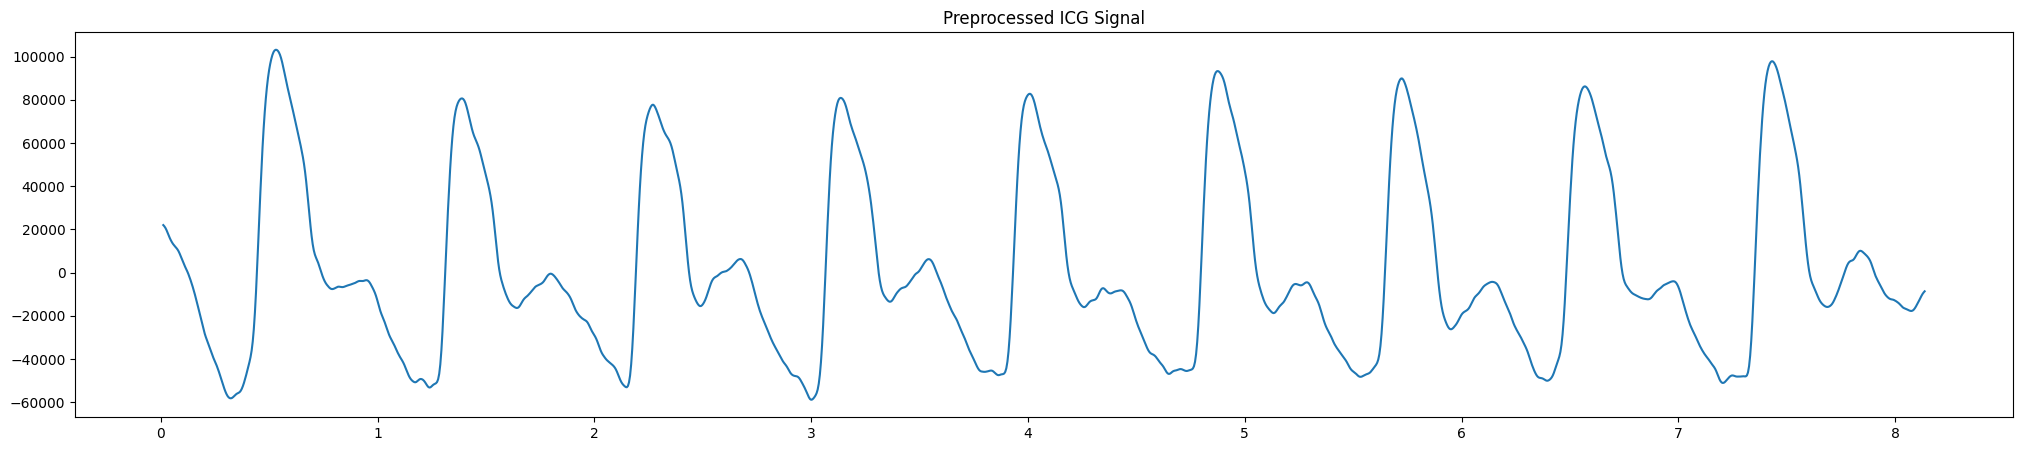

In [59]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    # Plot
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.4)
    plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG', alpha=0.7)
    plt.plot(icg_time, icg_detrended, label='Detrended ICG', linewidth=2)
    plt.legend()
    plt.title("ICG Signal: Raw, Band-passed, and Baseline-corrected")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return icg_detrended


icg_detrended = preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2)
plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_detrended)
plt.title("Preprocessed ICG Signal")

### Wavelet decomposition for electrode artifact
No effect

In [60]:
# import pywt

# # choose wavelet and decomposition level
# wavelet = 'db4'
# max_level = pywt.dwt_max_level(len(icg_data), pywt.Wavelet(wavelet).dec_len)
# level = min(5, max_level)  #safe max level

# # wavelet decomposition
# coeffs = pywt.wavedec(icg_data, wavelet, level=level)

# # estimate a threshold
# sigma = np.median(np.abs(coeffs[-1])) / 0.6745
# threshold = sigma * np.sqrt(2 * np.log(len(icg_data)))

# # soft thresholding to detail coefficients (ignore approximation at index 0)
# coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]

# # reconstruct denoised signal
# icg_denoised = pywt.waverec(coeffs_thresh, wavelet)

# plt.figure(figsize=(12, 4))
# plt.plot(icg_time, icg_data, label='Original ICG', alpha=0.6)
# plt.plot(icg_time, icg_denoised, label='Denoised ICG', linewidth=2)
# plt.legend()
# plt.xlabel("Time (s)")
# plt.ylabel("ICG Signal")
# plt.title("ICG Signal Before and After Wavelet Denoising")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


# ECG + Preprocess

Sampling Frequency ECG 1: 198.77 Hz
Sampling Frequency ECG 2: 43810.88 Hz
Sampling Frequency ECG 3: 136.00 Hz
Sampling Frequency ECG 4: 496.05 Hz


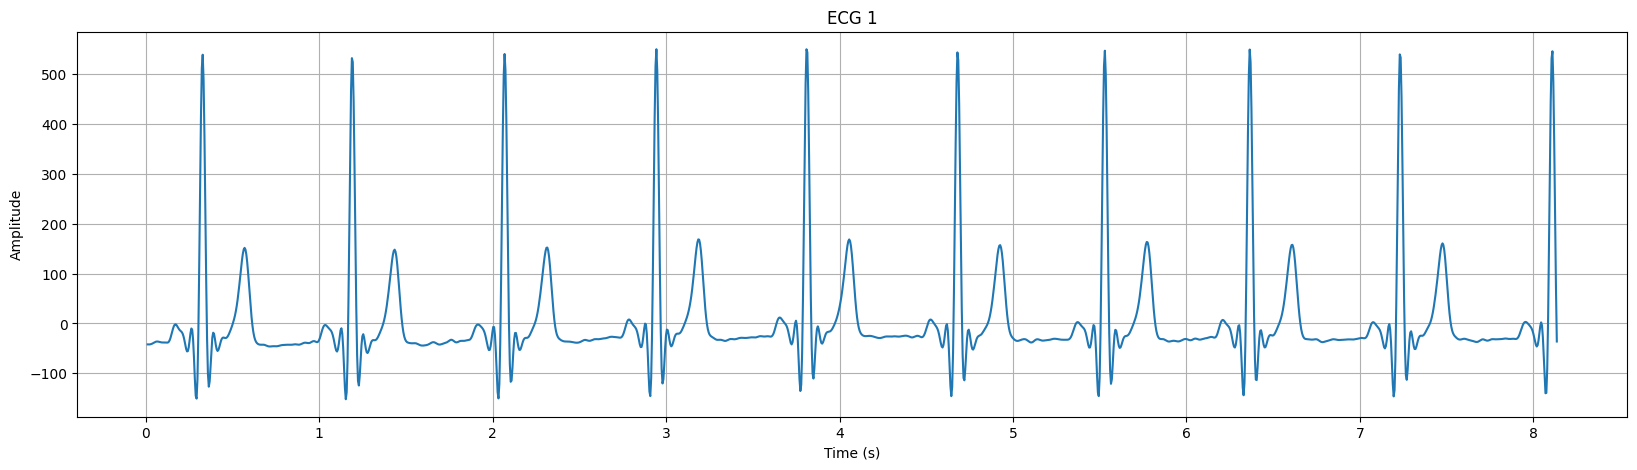

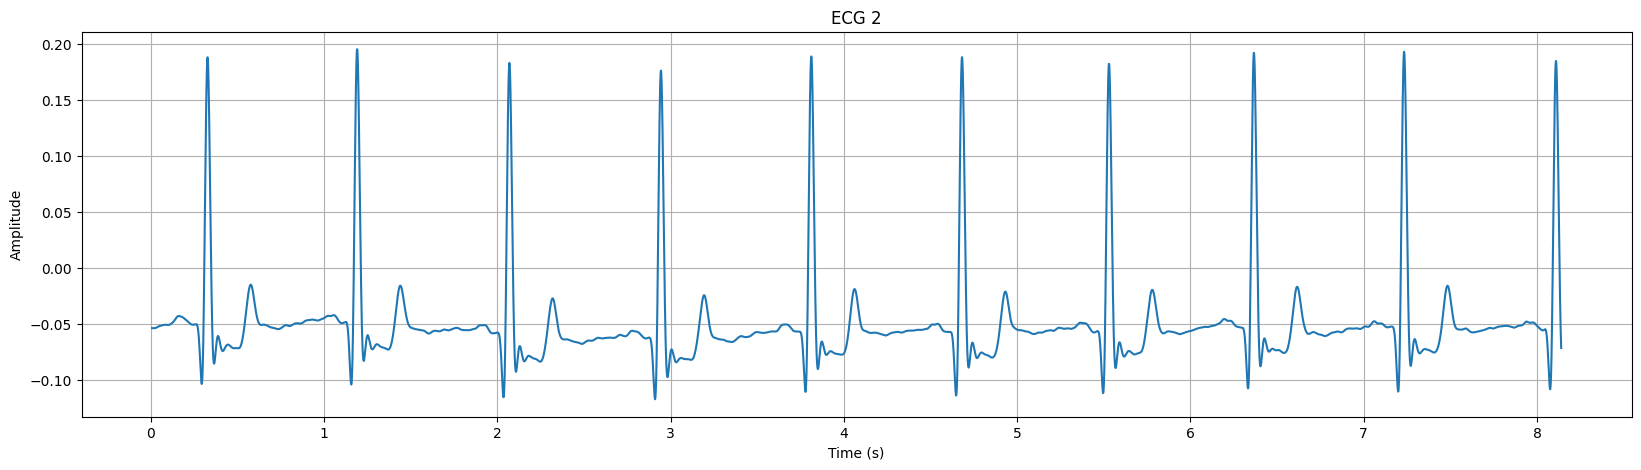

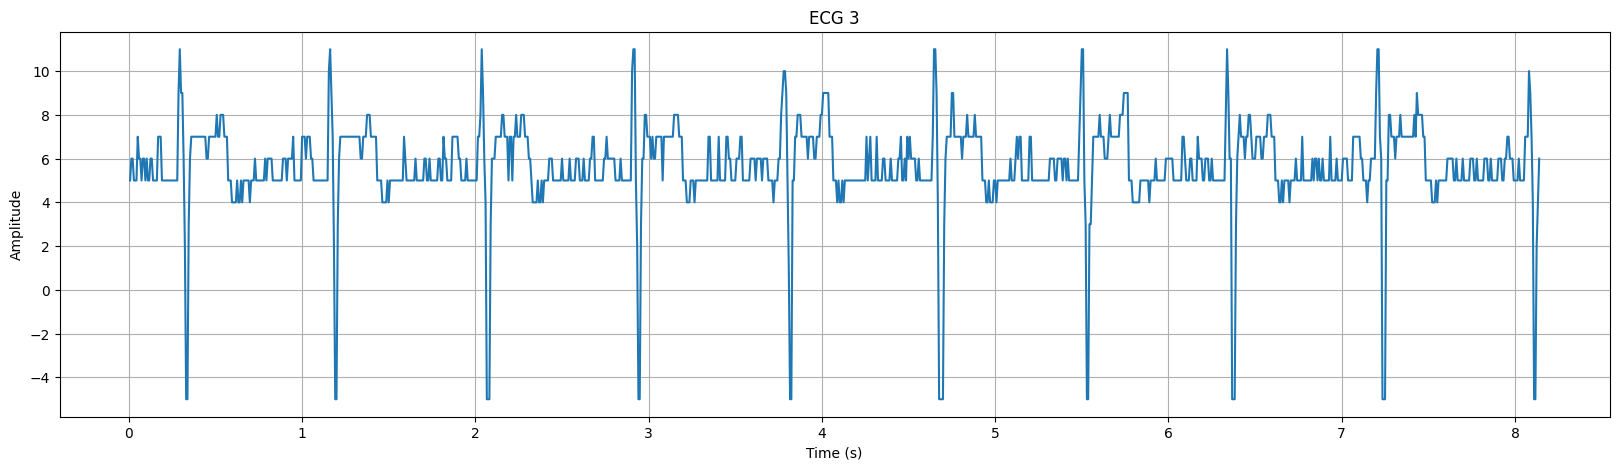

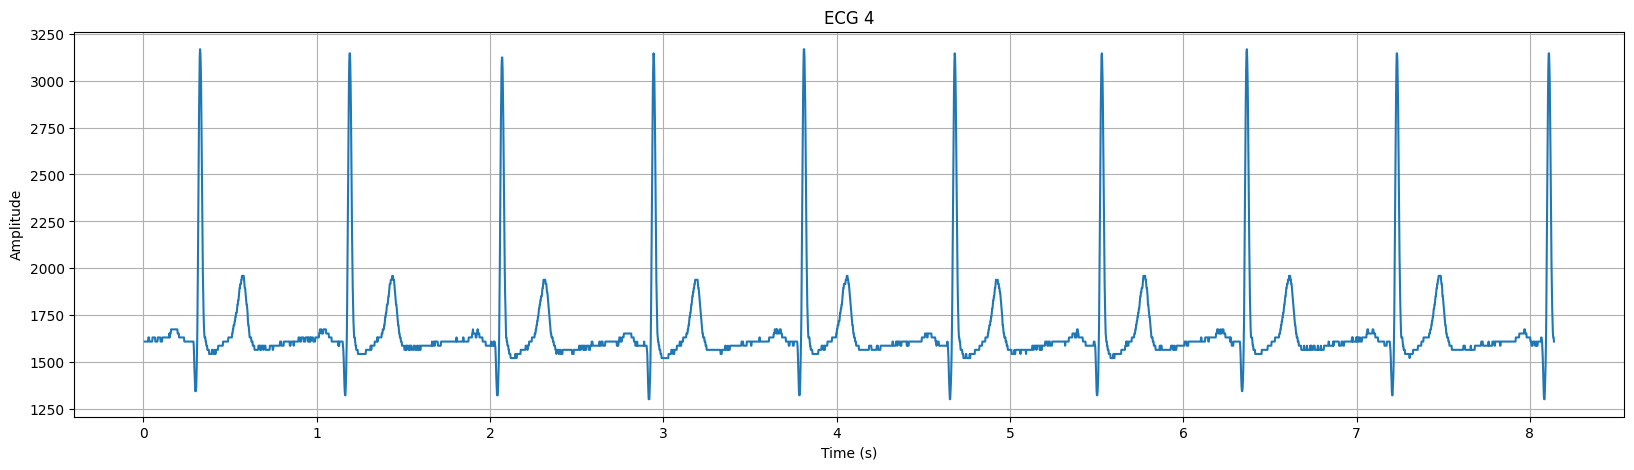

In [61]:
import matplotlib.pyplot as plt

ecg_1 = measures[0, 1]
ecg_2 = measures[0, 2]
ecg_3 = measures[0, 3]
ecg_4 = measures[0, 4]

ecg_1_time = ecg_1['time'][0, 0].flatten()
ecg_1_data = ecg_1['data'][0, 0].flatten()

ecg_2_time = ecg_2['time'][0, 0].flatten()
ecg_2_data = ecg_2['data'][0, 0].flatten()

ecg_3_time = ecg_3['time'][0, 0].flatten()
ecg_3_data = ecg_3['data'][0, 0].flatten()

ecg_4_time = ecg_4['time'][0, 0].flatten()
ecg_4_data = ecg_4['data'][0, 0].flatten()

# Plot ECG 1
plt.figure(figsize=(20, 5))
plt.plot(ecg_1_time, ecg_1_data)
plt.title('ECG 1')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 2
plt.figure(figsize=(20, 5))
plt.plot(ecg_2_time, ecg_2_data)
plt.title('ECG 2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 3
plt.figure(figsize=(20, 5))
plt.plot(ecg_3_time, ecg_3_data)
plt.title('ECG 3')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 4
plt.figure(figsize=(20, 5))
plt.plot(ecg_4_time, ecg_4_data)
plt.title('ECG 4')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

def get_sampling_frequency(time_array):
    time_diffs = np.diff(time_array)
    avg_time_step = np.mean(time_diffs)
    fs = 1 / avg_time_step
    return fs

fs_1 = get_sampling_frequency(ecg_1_time)
fs_2 = get_sampling_frequency(ecg_2_time)
fs_3 = get_sampling_frequency(ecg_3_time)
fs_4 = get_sampling_frequency(ecg_4_time)

print(f"Sampling Frequency ECG 1: {fs_1:.2f} Hz")
print(f"Sampling Frequency ECG 2: {fs_2:.2f} Hz")
print(f"Sampling Frequency ECG 3: {fs_3:.2f} Hz")
print(f"Sampling Frequency ECG 4: {fs_4:.2f} Hz")

## ECG Preprocessing
We see ECG 1 most times has some baseline drifts, we use a band pass, with band of choice 0.05 Hz - 150 Hz (recommended by American Hearth Association), but we cannot bc: ValueError: Digital filter critical frequencies must be 0 < Wn < 1

The high cutoff frequency is too high relative to the Nyquist frequency (nyq = fs_3 / 2). The butter function requires normalized cutoff frequencies between 0 and 1, where 1 represents the Nyquist frequency.

We see that the notch doesn't affect the data.


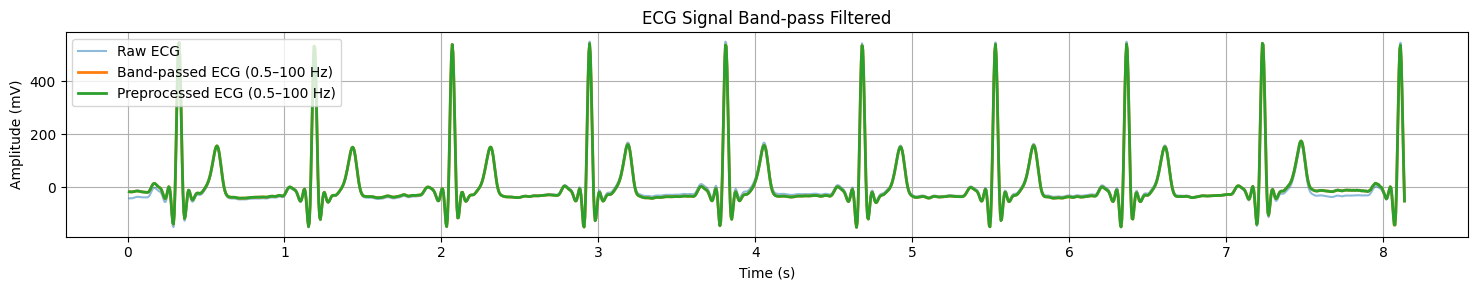

In [62]:
from scipy.signal import iirnotch

def notch_filter(data, fs, freq=50, quality_factor=30):
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, data)

ecg_1_bandpassed = bandpass(ecg_1_data, fs_1, 0.5,45)
ecg_1_preprocessed = notch_filter(ecg_1_bandpassed, fs_1, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_1_time, ecg_1_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_1_time, ecg_1_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_1_time, ecg_1_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

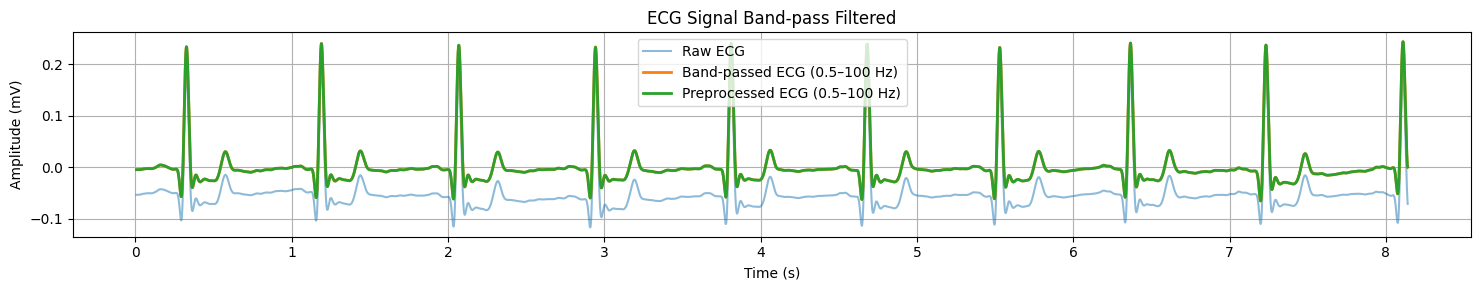

In [63]:
ecg_2_bandpassed = bandpass(ecg_2_data, fs_2, 0.5,100)
ecg_2_preprocessed = notch_filter(ecg_2_bandpassed, fs_2, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_2_time, ecg_2_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_2_time, ecg_2_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_2_time, ecg_2_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

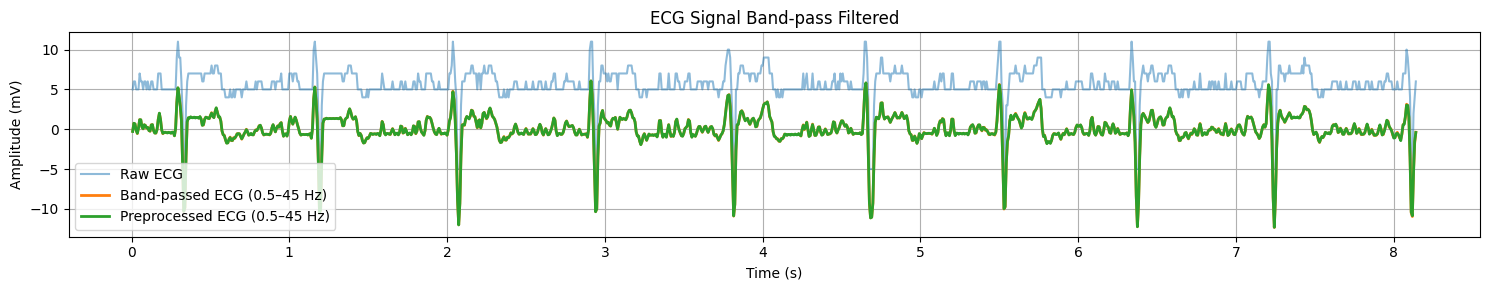

In [64]:
ecg_3_bandpassed = bandpass(ecg_3_data, fs_3, 0.5, 45)
ecg_3_preprocessed = notch_filter(ecg_3_bandpassed, fs_3, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_3_time, ecg_3_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_3_time, ecg_3_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_3_time, ecg_3_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


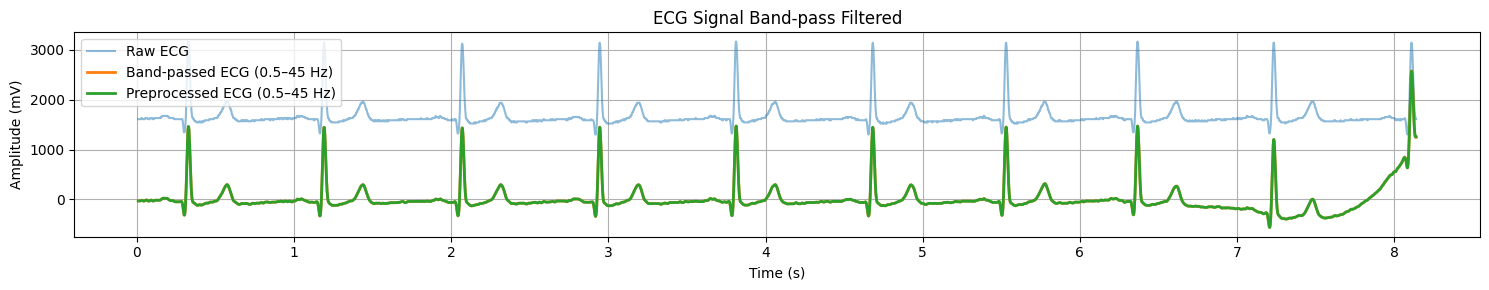

In [65]:
ecg_4_bandpassed = bandpass(ecg_4_data, fs_4, 0.5, 45)
ecg_4_preprocessed = notch_filter(ecg_4_bandpassed, fs_4, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_4_time, ecg_4_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_4_time, ecg_4_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_4_time, ecg_4_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Echo

(274, 1107)


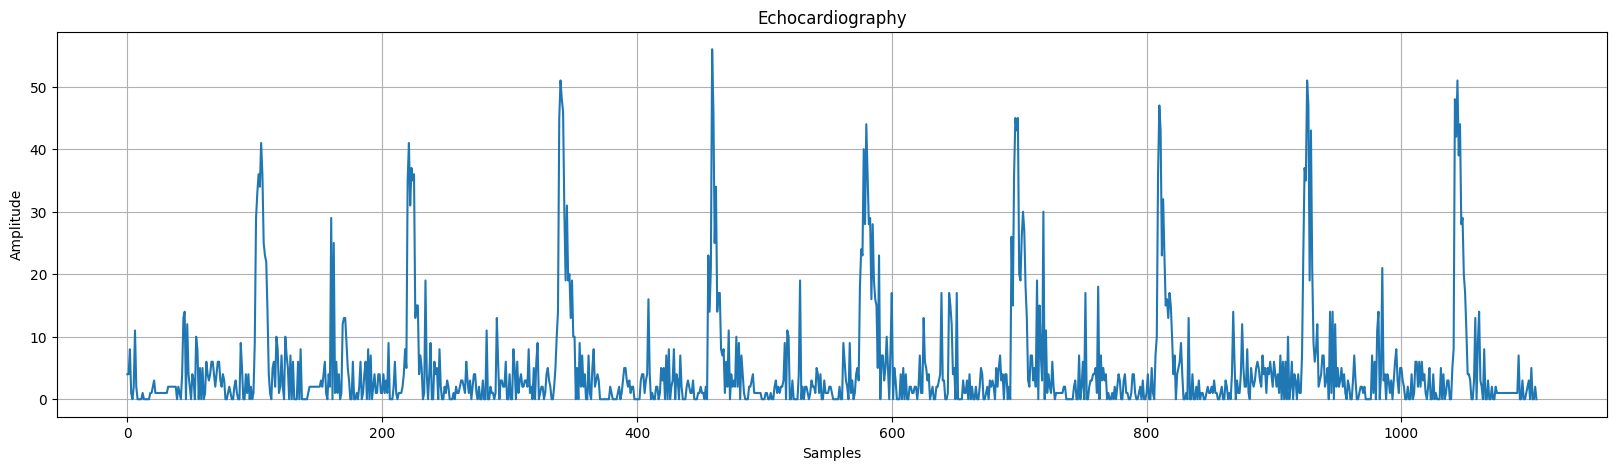

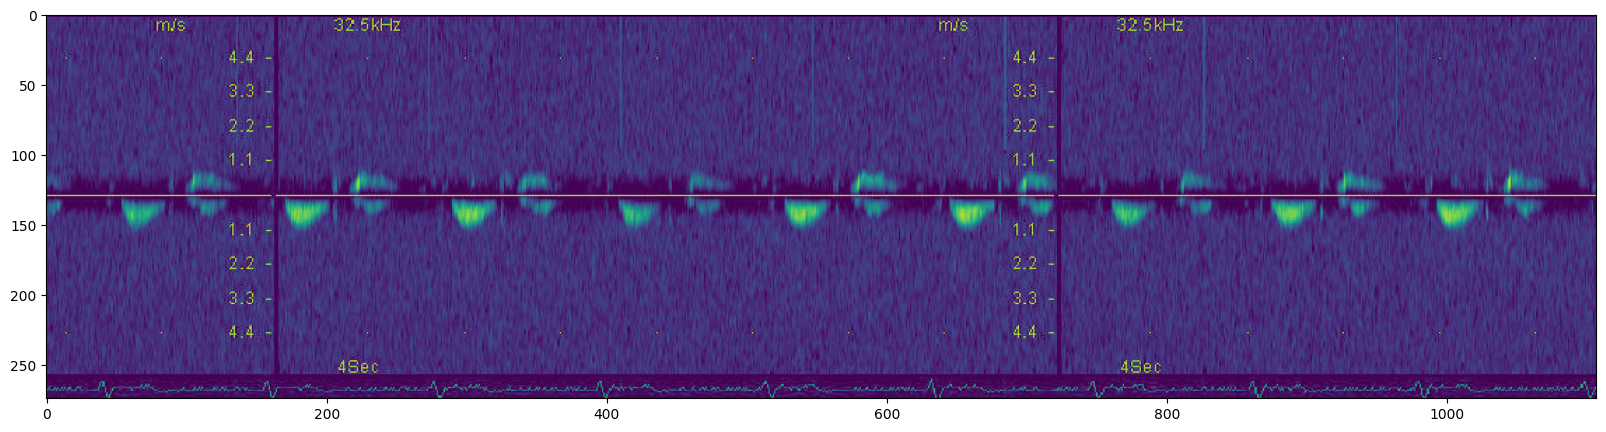

In [66]:
# since the sizes of the variables dont match -> truncate echo_data to match the length of echo_time
# echo_data_trunc = echo_data[:len(echo_time)]

# plt.figure(figsize=(20, 5))
# plt.plot(echo_time, echo_data_trunc)
# plt.title('Echocardiography')
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.grid(True)
# plt.show()

echo = measures[1,3]
echo_time = echo['time']
echo_data = echo['data']
echo_value = echo_data[0, 0]

echo_value_1 = echo_value[:, :, 0]  #all time frames, channel 0, covering all depth points
print(echo_value_1.shape)
#it means we extract all lines

echo_one_line = echo_value[130, :, 0] #we see in the echo picture that not all depths are information so we choose one that helps finding AVO and AVC
plt.figure(figsize=(20, 5))
plt.plot(echo_one_line)
plt.title('Echocardiography')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plt.imshow(echo_value_1)


274
[ 6  0 15 ...  2 11  3]


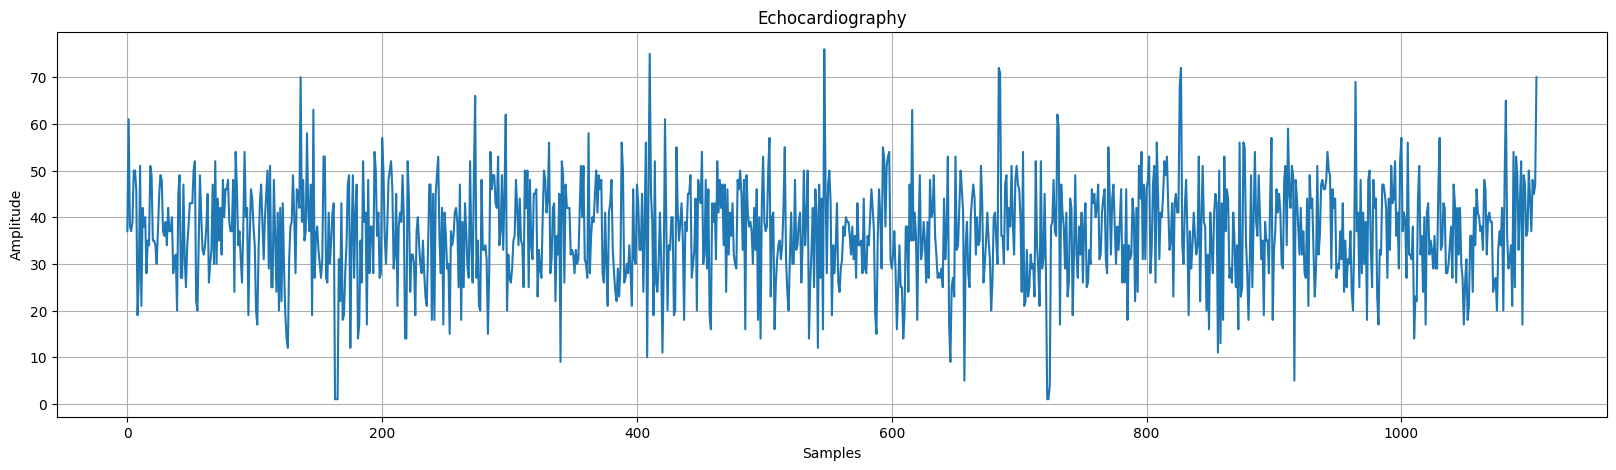

In [67]:
depth_count = echo_value.shape[0]

all_echo_lines = []

for i in range(depth_count):
    echo_value_i = echo_data[0, 0][i, :, 0]  # or echo_value[i, :, 0] if echo_value is still valid
    all_echo_lines.append(echo_value_i)

print(len(all_echo_lines)) #274 lines
print(all_echo_lines[131])

plt.figure(figsize=(20, 5))
plt.plot(all_echo_lines[90])
plt.title('Echocardiography')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# we extract all lines to use it later

# R peaks

### ECG + ICG + R peaks

[0.32806249 1.18836953 2.06880071 2.94420086 3.80953893 4.67990805
 5.53015302 6.36530488 7.23064296 8.11107414]


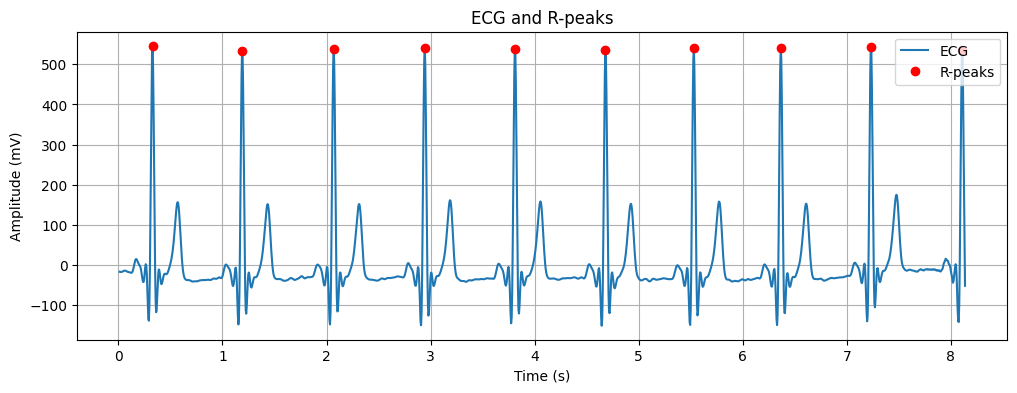

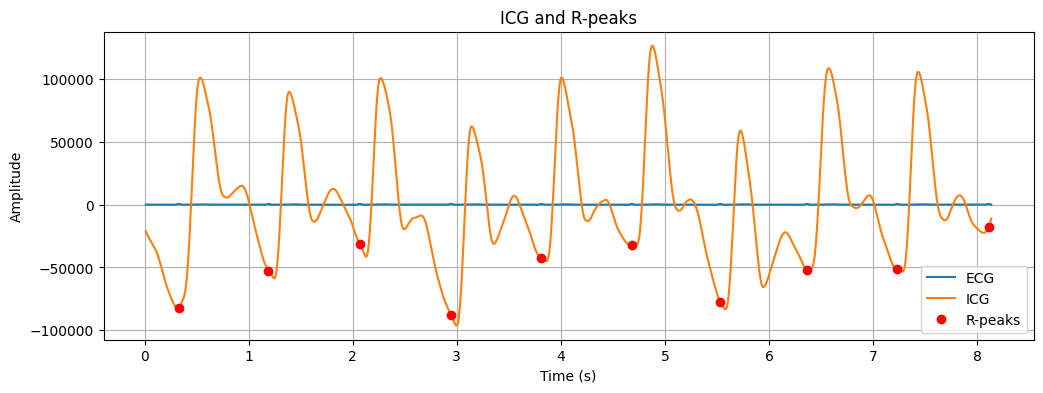

In [68]:
rpeaks = measures[2,1]
rpeaks_time = rpeaks['time'][0,0].flatten()
rpeaks_values = rpeaks['data'][0,0].flatten()
#print(rpeaks_values)

# numpy array?
rpeaks_times = np.array(rpeaks_values)
print(rpeaks_times)

# find the closest points to the time second
rpeaks_index = np.array([np.argmin(np.abs(ecg_1_time - t)) for t in rpeaks_times])

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed, label='ECG')
plt.plot(ecg_1_time[rpeaks_index], ecg_1_preprocessed[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed,label='ECG')
plt.plot(icg_time, icg_sg, label='ICG')
plt.plot(icg_time[rpeaks_index], icg_sg[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points, also it puts it in the amplitude where the signal is
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


We see that ECG is much more flat because it's not scaled well, we normalise between 0 and 1 to see them properly

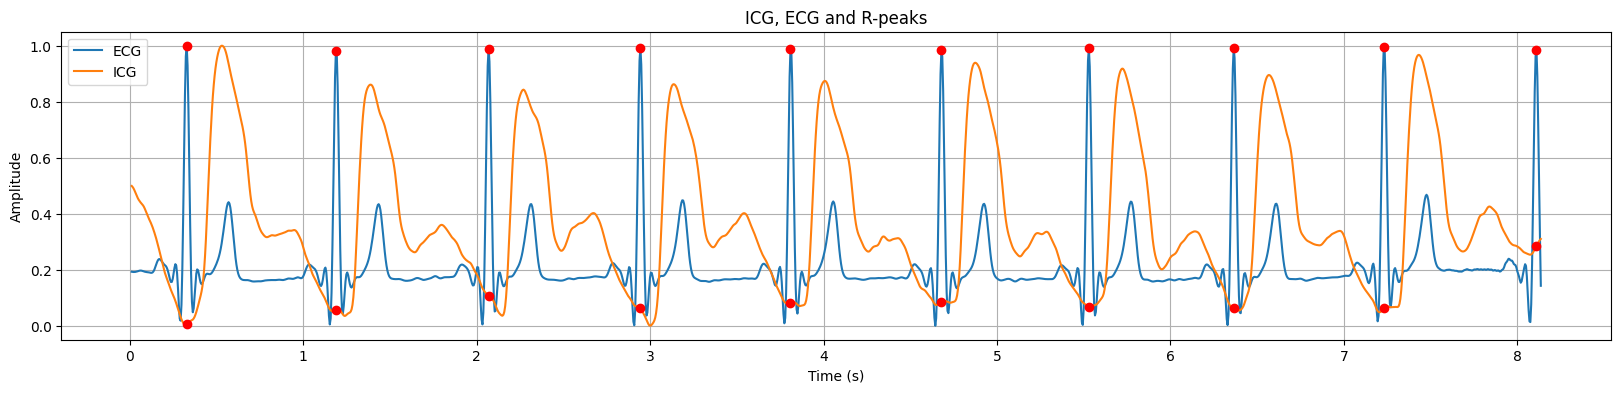

In [69]:
def normalize(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

ecg_norm = normalize(ecg_1_preprocessed)
icg_norm = normalize(icg_detrended)

plt.figure(figsize=(20, 4))
plt.plot(ecg_1_time, ecg_norm, label='ECG')
plt.plot(icg_time, icg_norm, label='ICG')
plt.plot(ecg_1_time[rpeaks_index], ecg_norm[rpeaks_index], 'ro')
plt.plot(icg_time[rpeaks_index], icg_norm[rpeaks_index],'ro')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG, ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


# Signal correlation
## Pearson's test

Weak but statistically significant positive correlation (r ≈ 0.16, p < 0.001) between the preprocessed ICG and ECG signals, suggesting a modest linear relationship after preprocessing.

Negligible and non-significant correlation (r ≈ 0.04, p ≈ 0.14) in raw data.

The preprocessing enhances the relationship of the signals. However, the overall low correlation values suggest that ICG and ECG signals are not strongly correlated.

In [70]:
from scipy.stats import pearsonr

# ICG preprocessed and ECG preprocessed
correlation_coefficient, p_value = pearsonr(icg_detrended, ecg_1_preprocessed)

print(f"Pearson's Correlation Coefficient Preprocessed: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG raw and ECG raw
correlation_coefficient, p_value = pearsonr(icg_data, ecg_1_data)

print(f"Pearson's Correlation Coefficient Raw: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG raw and ECG preprocessed
correlation_coefficient, p_value = pearsonr(icg_data, ecg_1_preprocessed)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG preprocessed and ECG raw
correlation_coefficient, p_value = pearsonr(icg_detrended, ecg_1_data)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and ECG raw
correlation_coefficient, p_value = pearsonr(icg_bandpassed, ecg_1_data)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and ECG preprocessed
correlation_coefficient, p_value = pearsonr(icg_bandpassed, ecg_1_preprocessed)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and ECG bandpassed
correlation_coefficient, p_value = pearsonr(icg_bandpassed, ecg_1_bandpassed)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and echo line
#correlation_coefficient, p_value = pearsonr(icg_bandpassed, all_echo_lines[90])

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Pearson's Correlation Coefficient Preprocessed: 0.0887399750280193
P-value: 0.0003548199515022722
Pearson's Correlation Coefficient Raw: 0.015863140135567437
P-value: 0.5239704828003942
Pearson's Correlation Coefficient: 0.022627062684610302
P-value: 0.36334527034941155
Pearson's Correlation Coefficient: 0.08600956409372443
P-value: 0.0005376097266899515
Pearson's Correlation Coefficient: 0.07281344192527286
P-value: 0.003403967303571549
Pearson's Correlation Coefficient: 0.07349479660884352
P-value: 0.003114888221001448
Pearson's Correlation Coefficient: 0.07349193588605048
P-value: 0.0031160537049496648
Pearson's Correlation Coefficient: 0.07349193588605048
P-value: 0.0031160537049496648


In [71]:
import pandas as pd
from scipy.stats import pearsonr

results = []

# 1. ICG preprocessed vs ECG preprocessed
r, p = pearsonr(icg_detrended, ecg_1_preprocessed)
results.append(["ICG Preprocessed", "ECG Preprocessed", r, p])

# 2. ICG Raw vs ECG Raw
r, p = pearsonr(icg_data, ecg_1_data)
results.append(["ICG Raw", "ECG Raw", r, p])

# 3. ICG Raw vs ECG Preprocessed
r, p = pearsonr(icg_data, ecg_1_preprocessed)
results.append(["ICG Raw", "ECG Preprocessed", r, p])

# 4. ICG Preprocessed vs ECG Raw
r, p = pearsonr(icg_detrended, ecg_1_data)
results.append(["ICG Preprocessed", "ECG Raw", r, p])

# 5. ICG Bandpassed vs ECG Raw
r, p = pearsonr(icg_bandpassed, ecg_1_data)
results.append(["ICG Bandpassed", "ECG Raw", r, p])

# 6. ICG Bandpassed vs ECG Preprocessed
r, p = pearsonr(icg_bandpassed, ecg_1_preprocessed)
results.append(["ICG Bandpassed", "ECG Preprocessed", r, p])

# 7. ICG Bandpassed vs ECG Bandpassed
r, p = pearsonr(icg_bandpassed, ecg_1_bandpassed)
results.append(["ICG Bandpassed", "ECG Bandpassed", r, p])

# Create DataFrame
df = pd.DataFrame(results, columns=["ICG Signal", "ECG Signal", "Pearson's r", "P-value"])
df_rounded = df.copy()
df_rounded[["Pearson's r", "P-value"]] = df_rounded[["Pearson's r", "P-value"]].round(6)

print(df_rounded)



         ICG Signal        ECG Signal  Pearson's r   P-value
0  ICG Preprocessed  ECG Preprocessed     0.088740  0.000355
1           ICG Raw           ECG Raw     0.015863  0.523970
2           ICG Raw  ECG Preprocessed     0.022627  0.363345
3  ICG Preprocessed           ECG Raw     0.086010  0.000538
4    ICG Bandpassed           ECG Raw     0.072813  0.003404
5    ICG Bandpassed  ECG Preprocessed     0.073495  0.003115
6    ICG Bandpassed    ECG Bandpassed     0.073492  0.003116


# ICG ReBeat delineation algorithm

### C point detection

In [72]:
rr_int = np.diff(rpeaks_times) #rr intervals
print(rr_int)

[0.86030704 0.88043118 0.87540015 0.86533808 0.87036911 0.85024497
 0.83515186 0.86533808 0.88043118]


In [73]:
def find_c_peaks(icg, rr_int):
    """
    Finds the maximum value (C peak) within each RR interval in the ICG signal.

    Input:
        icg: The preprocessed ICG signal.
        rr_int:  The RR intervals (beat-to-beat intervals).

    Output:
        A list of C peak values.
    """
    c_peaks = []
    start_index = 0
    for rr in rr_int:
        end_index = start_index + int(round(rr * fs)) # Convert seconds to samples
        if end_index >= len(icg_sg):
            end_index = len(icg_sg) -1 #handle edge cases where the end_index exceeds the signal length
        c_peaks.append(np.max(icg_sg[start_index:end_index]))
        start_index = end_index
    return c_peaks

c_peaks_values = find_c_peaks(icg_detrended, rr_int)
print("C-peak values:", c_peaks_values)

C-peak values: [np.float64(100992.1090337694), np.float64(89767.484146359), np.float64(100708.73034142109), np.float64(62215.66964823908), np.float64(100974.62602529002), np.float64(126344.1092542966), np.float64(58817.82835039141), np.float64(108394.95776525153), np.float64(105538.23458823086)]


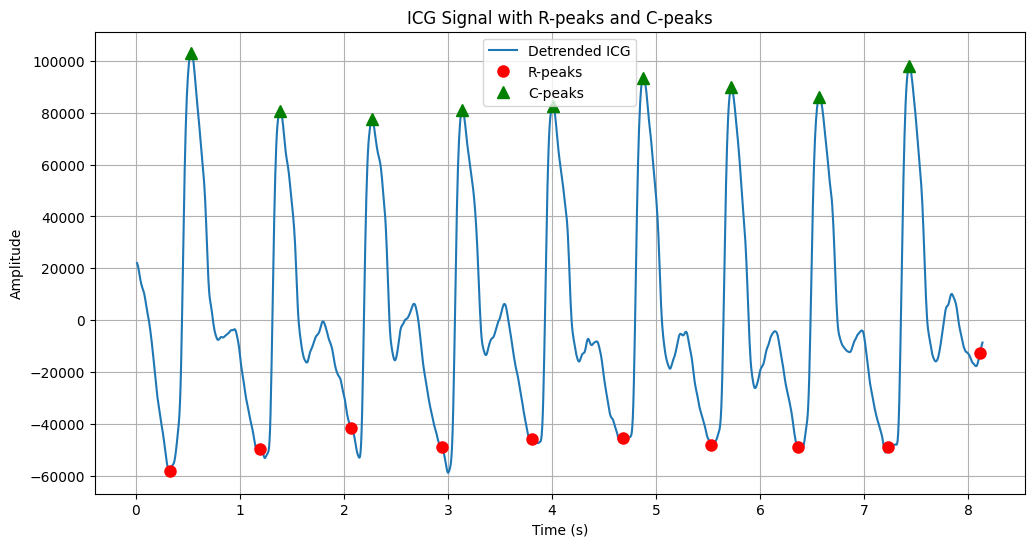

In [78]:
# Find the indices of the R-peaks in the ICG signal's time vector
rpeaks_index = np.array([np.argmin(np.abs(icg_time - t)) for t in rpeaks_times])

# Plot the C peaks over the ICG
plt.figure(figsize=(12, 6))
plt.plot(icg_time, icg_detrended, label='Detrended ICG')
plt.plot(icg_time[rpeaks_index], icg_detrended[rpeaks_index], 'ro', markersize=8, label='R-peaks')

# Calculate RR intervals (if not already defined)
rr_int = np.diff(rpeaks_times)

C_peak_times = []
C_peaks_values = []  # Added to store amplitude values
start_index = 0
for i, rr in enumerate(rr_int):
    end_index = start_index + int(round(rr * fs))
    if end_index >= len(icg_detrended):
        end_index = len(icg_detrended) - 1
    current_max_idx = start_index + np.argmax(icg_detrended[start_index:end_index])
    C_peak_times.append(icg_time[current_max_idx])
    C_peaks_values.append(icg_detrended[current_max_idx])  # Store amplitude
    start_index = rpeaks_index[i+1]  # Move to next R-peak index

# Plot C-peaks (fixed the string quote and variable name)
plt.plot(C_peak_times, C_peaks_values, 'g^', markersize=8, label='C-peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG Signal with R-peaks and C-peaks')
plt.legend()
plt.grid(True)
plt.show()

### B points
the B point is detected as the sign change within 20% and 65% of the R–C interval window of the ICG first derivative [ReBeat]

15% response from the baseline [14 de Systematic Variability]

equation that relates the R peak of the electrocardiography (ECG) signal and the C peak of the dZ/dt signal; RB = 1.233RE -0.0032RE2 - 31.59 [11 de Systematic Variability]

B-points: [nan, nan, np.float64(-52995.58635986502), np.float64(-58894.27746911357), np.float64(-47424.093616985054), np.float64(-45559.31926915085), nan, nan, np.float64(-48010.35323960983)]
B-times: [nan, nan, np.float64(2.1442662394482728), np.float64(2.999542245598839), np.float64(3.8598492870797063), np.float64(4.730218399221172), nan, nan, np.float64(7.296046417672873)]


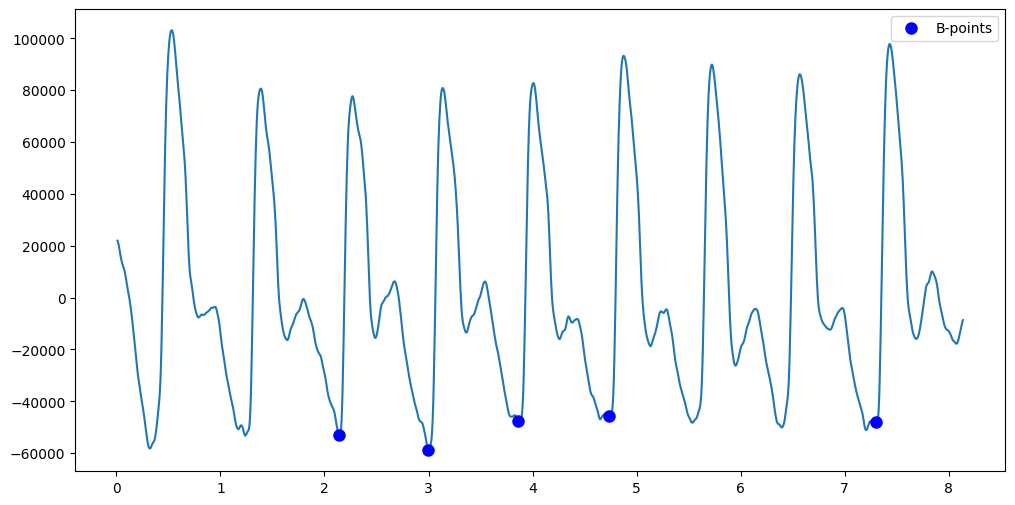

In [79]:
import matplotlib.pyplot as plt
import numpy as np
def find_b_points(icg_detrended, rpeaks_times, rr_int, fs, icg_time):
    b_points = []
    b_times = []

    start_index = 0
    for i, rr in enumerate(rr_int):
        end_index = start_index + int(round(rr * fs))
        if end_index >= len(icg_detrended):
            end_index = len(icg_detrended) - 1

        # Find C peak within the RR interval
        c_peak_index = start_index + np.argmax(icg_detrended[start_index:end_index])
        c_peak_time = icg_time[c_peak_index]

        # Calculate the R-C interval
        r_peak_time = rpeaks_times[i]
        rc_interval = c_peak_time - r_peak_time

        # Define the window for B point search (15% of the baseline)
        baseline_start = int(r_peak_time*fs)
        window_start_index = int(baseline_start + 0.20 * rc_interval * fs)
        window_end_index = int(baseline_start + 0.65 * rc_interval * fs)


        # Ensure window indices are within the valid range
        window_start_index = max(0, min(window_start_index, len(icg_detrended) - 1))
        window_end_index = max(0, min(window_end_index, len(icg_detrended) - 1))

        # Calculate the first derivative of ICG within the window
        icg_derivative = np.gradient(icg_detrended[window_start_index:window_end_index])

        # Find the index of the first sign change in the derivative
        sign_changes = np.where(np.diff(np.sign(icg_derivative)))[0]
        if sign_changes.size > 0:
            b_point_index_in_window = sign_changes[0]
            b_point_index = window_start_index + b_point_index_in_window
            b_points.append(icg_detrended[b_point_index])
            b_times.append(icg_time[b_point_index])
        else:
            b_points.append(np.nan)  # Or handle the case where no sign change is found
            b_times.append(np.nan)

        start_index = end_index

    return b_points, b_times

# Example usage (assuming you have icg_detrended, rpeaks_times, rr_int, fs, and icg_time defined)
b_points, b_times = find_b_points(icg_detrended, rpeaks_times, rr_int, fs, icg_time)

print("B-points:", b_points)
print("B-times:", b_times)

plt.figure(figsize=(12,6))
plt.plot(icg_time, icg_detrended)
plt.plot(b_times, b_points, 'bo', markersize = 8, label = 'B-points')
plt.legend()
plt.show()
